<a href="https://colab.research.google.com/github/siddharth2004agrawal/AiProject1/blob/AiModules%2Fmodule-14/Day14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Object Detection in Video

In [1]:
!pip install ultralytics opencv-python --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 1.3 MB/s eta 0:00:00


In [3]:
import cv2
from ultralytics import YOLO
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
import os

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [18]:
video_path = "/content/input_video.mp4"

Removing existing file: /content/input_video.mp4
--2026-07-17 18:13:54--  https://www.learningcontainer.com/wp-content/uploads/2020/05/sample-mp4-file.mp4
Resolving www.learningcontainer.com (www.learningcontainer.com)... 104.21.84.74, 172.67.188.164, 2606:4700:3037::ac43:bca4, ...
Connecting to www.learningcontainer.com (www.learningcontainer.com)|104.21.84.74|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10546620 (10M) [video/mp4]
Saving to: ‘/content/input_video.mp4’

/content/input_vide 100%[===================>]  10.06M  --.-KB/s    in 0.1s    

2026-07-17 18:13:55 (105 MB/s) - ‘/content/input_video.mp4’ saved [10546620/10546620]

Download complete. File size: 10299.4 KB
YOLOv8n model loaded successfully.
Original Video Properties: FPS=15, Width=320, Height=240
Processing video: /content/input_video.mp4. Saving output to: output_detection_video_2.mp4
This might take a while, processing up to 500 frames.

0: 480x640 1 cow, 305.3ms
Speed: 6.0ms preprocess

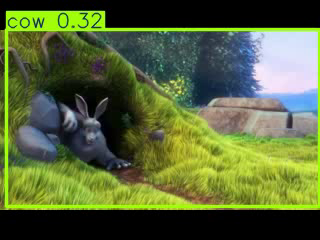

Frame 2 from output video:


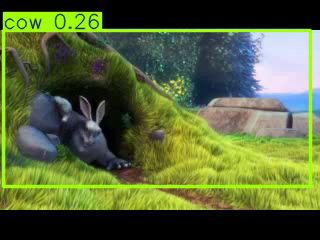

Frame 3 from output video:


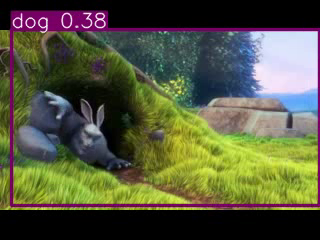

Frame 4 from output video:


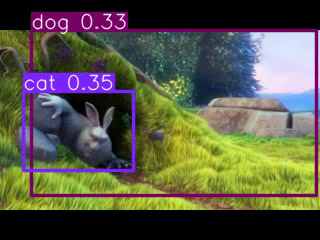

Frame 5 from output video:


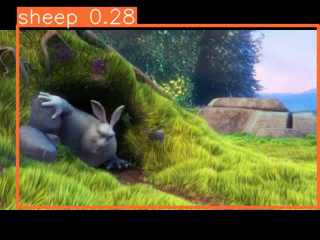

Frame 6 from output video:


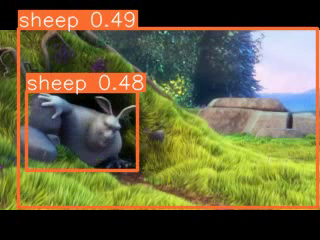

Frame 7 from output video:


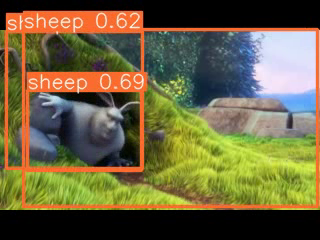

Frame 8 from output video:


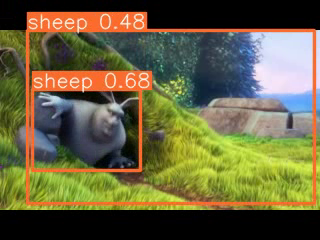

Frame 9 from output video:


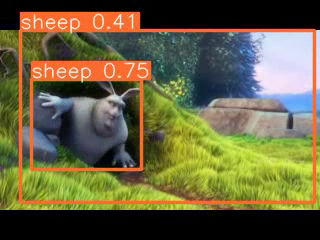

Frame 10 from output video:


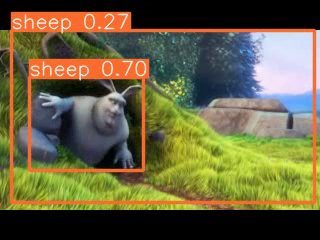

Frame 11 from output video:


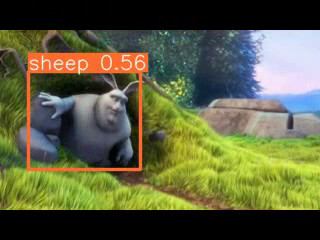

Frame 12 from output video:


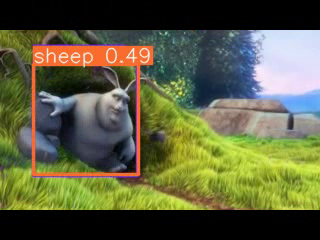

Frame 13 from output video:


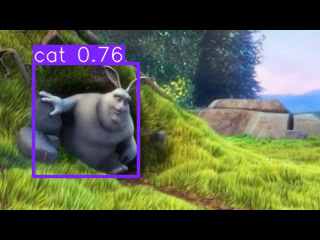

Frame 14 from output video:


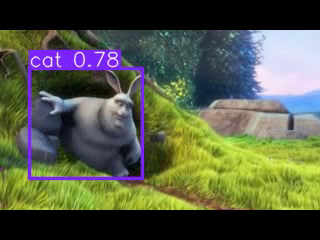

Frame 15 from output video:


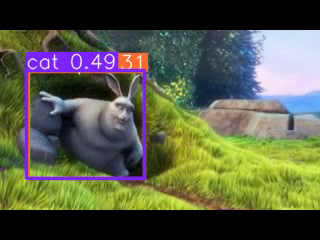

Frame 16 from output video:


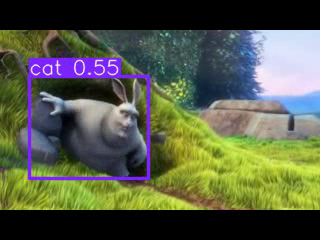

Frame 17 from output video:


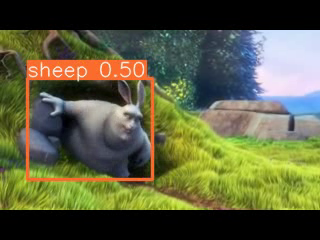

Frame 18 from output video:


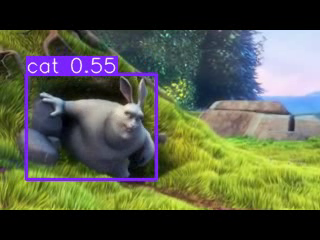

Frame 19 from output video:


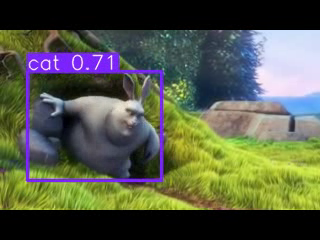

Frame 20 from output video:


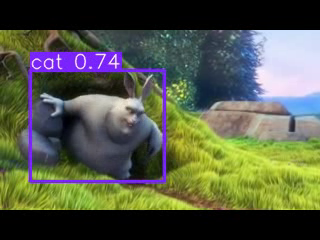

Frame 21 from output video:


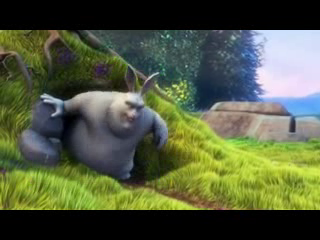

Frame 22 from output video:


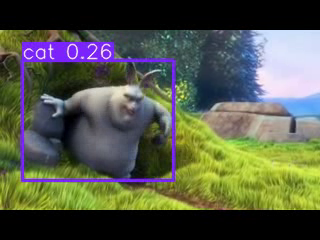

Frame 23 from output video:


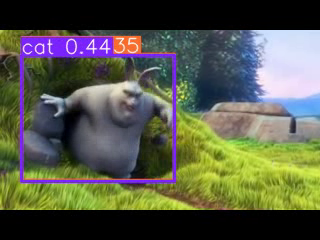

Frame 24 from output video:


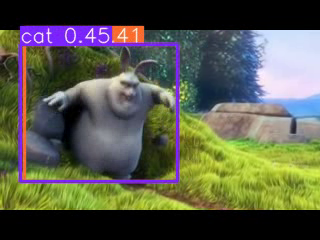

Frame 25 from output video:


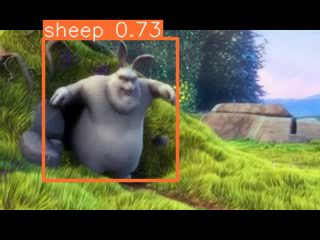

Frame 26 from output video:


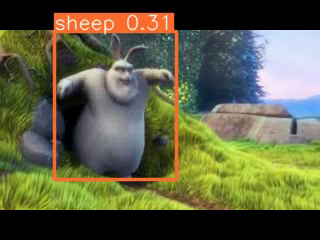

Frame 27 from output video:


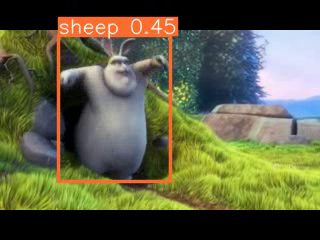

Frame 28 from output video:


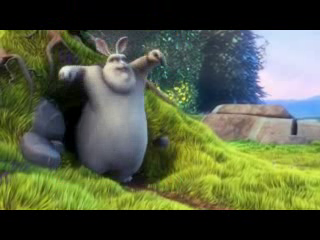

Frame 29 from output video:


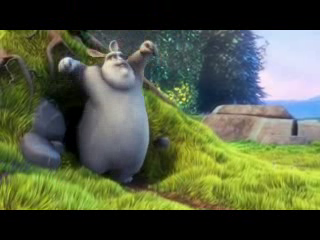

Frame 30 from output video:


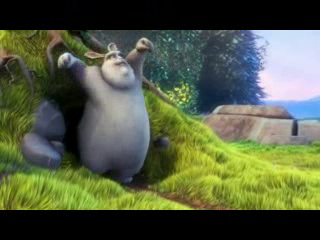

Frame 31 from output video:


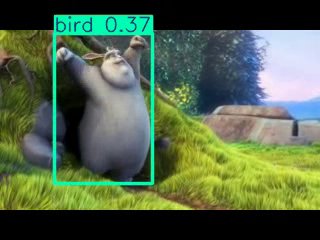

Frame 32 from output video:


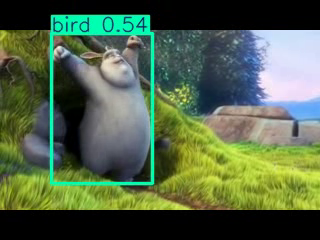

Frame 33 from output video:


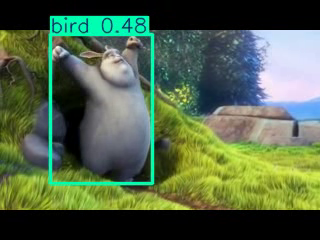

Frame 34 from output video:


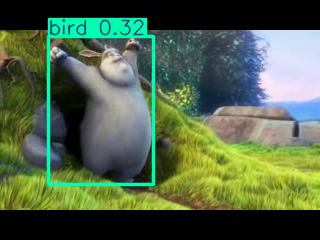

Frame 35 from output video:


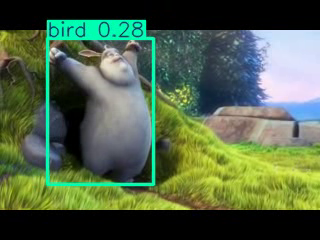

Frame 36 from output video:


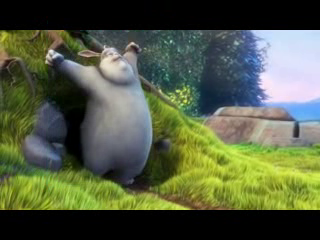

Frame 37 from output video:


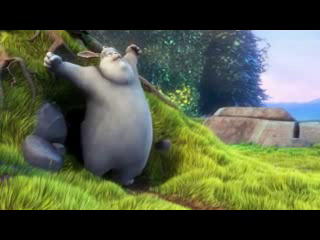

Frame 38 from output video:


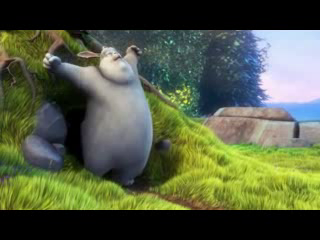

Frame 39 from output video:


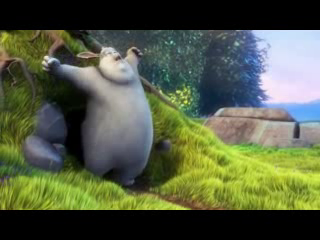

Frame 40 from output video:


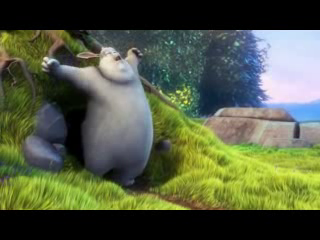

Frame 41 from output video:


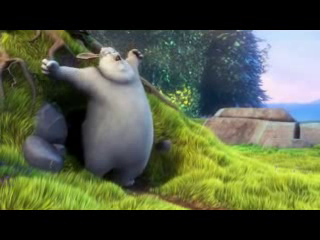

Frame 42 from output video:


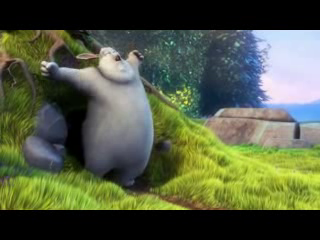

Frame 43 from output video:


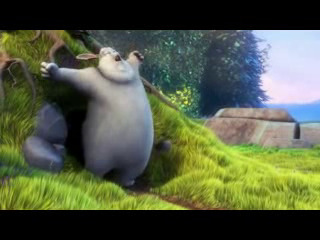

Frame 44 from output video:


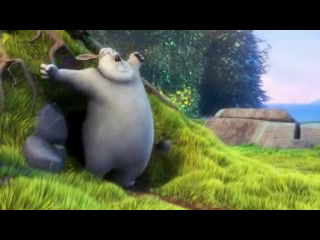

Frame 45 from output video:


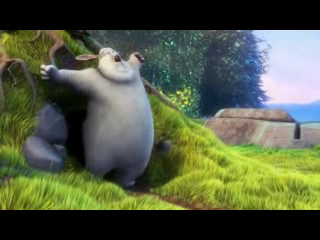


You can also download the full processed video from: output_detection_video_2.mp4


In [22]:
# NOTE: Please replace this placeholder with the actual URL of your video.
video_url = "https://www.learningcontainer.com/wp-content/uploads/2020/05/sample-mp4-file.mp4"
# A publicly accessible video URL

if os.path.exists(video_path):
  print(f"Removing existing file: {video_path}")
  os.remove(video_path)

print(f"Downloading sample video to {video_path} from {video_url}...")
# Ensure video_path is quoted to handle spaces correctly, even if the new path has none, it's a good practice
!wget -O "{video_path}" "{video_url}"

if os.path.exists(video_path):
  size_kb = os.path.getsize(video_path) / 1024
  print(f"Download complete. File size: {size_kb:.1f} KB")
  if size_kb < 10:
    print("WARNING: File is very small, it may not be a valid video (check for an HTML error page).")

  model = YOLO('yolov8n.pt')
  print("YOLOv8n model loaded successfully.")
  input_video_path = video_path
  output_video_path = "output_detection_video_2.mp4"
  cap = cv2.VideoCapture(input_video_path)
  if not cap.isOpened():
    print(f"Error: Could not open video file {input_video_path}. Please check the file path or if it's corrupted.")
  else:
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    print(f"Original Video Properties: FPS={fps}, Width={width}, Height={height}")

    if fps <= 0:
      print("Warning: FPS is 0 or less. Setting to default 24 FPS.")
      fps = 24
    # These checks should be independent, not nested under fps check
    if width <= 0:
      print("Warning: Width is 0 or less. Setting to default 1280 pixels.")
      width = 1280
    if height <= 0:
      print("Warning: Height is 0 or less. Setting to default 720 pixels.")
      height = 720

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    # Codec for .mp4 files
    out = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))
    if not out.isOpened():
      print(f"Error: Could not open video writer for {output_video_path}. Check codec or file permissions.")
    else:
      frame_count = 0
      MAX_FRAMES_TO_PROCESS = 500
      print(f"Processing video: {input_video_path}. Saving output to: {output_video_path}")
      print(f"This might take a while, processing up to {MAX_FRAMES_TO_PROCESS} frames.")

      while cap.isOpened() and frame_count < MAX_FRAMES_TO_PROCESS:
        ret, frame = cap.read()
        if not ret:
          print(f"End of video or failed to read frame at frame_count {frame_count}.")
          break

        results = model(frame)
        annotated_frame = results[0].plot()
        if annotated_frame.shape[1] != width or annotated_frame.shape[0] != height:
          annotated_frame = cv2.resize(annotated_frame, (width, height))
        out.write(annotated_frame)
        frame_count += 1
        if frame_count % 50 == 0:
          print(f"Processed {frame_count} frames...")

      # Ensure cap.release() and out.release() are called after the loop finishes
      cap.release()
      out.release()
      print(f"Video processing complete. Output saved to {output_video_path}")

      # --- Start of display frames logic (moved and fixed) ---
      display_frames = 45
      displayed_count = 0
      cap_output = cv2.VideoCapture(output_video_path)

      if not cap_output.isOpened():
          print(f"Error: Could not open output video file {output_video_path} for display.")
      else:
          print(f"\nDisplaying first {display_frames} frames from output video:")
          while cap_output.isOpened() and displayed_count < display_frames:
            ret_display, frame_display = cap_output.read()
            if not ret_display:
              print(f"End of output video or failed to read frame at frame_display_count {displayed_count}.")
              break
            print(f"Frame {displayed_count + 1} from output video:")
            cv2_imshow(frame_display)
            displayed_count += 1

          cap_output.release()
          print(f"\nYou can also download the full processed video from: {output_video_path}")
      # --- End of display frames logic ---

else:
  print("ERROR: Download failed, file was not created at the specified path.")